<a href="https://colab.research.google.com/github/vanshdhiman090/Bellabeat_Case_Study_Journal_mar26/blob/main/Natural_Language_Processing_context_analysis_Aprip26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spotify App Review (Natural Language Processing)

 Analyze Spotify app reviews using NLP to understand user sentiment, key issues, and improvement opportunities.

 Editor = **Vansh**

 Date = **08/Apr/2026**

# Process
Ask -
Prepare -
Process -
Analyse -
Share -
Act.

# Ask Phase

### Stakeholders

Vansh (i try to learn thats why i create this project)

### Key Questions


What is the overall sentiment distribution of reviews?

What are the most common complaints?

What features do users like most?

Are there patterns in negative reviews?



# Prepare Phase

Data is the internal from there own Spotify website.

**Data types**

**Time_submitted** - Quantiattive / Structured

**Review** - Quantitative / Unstuctured

**Rating** - Quantitative / Structured

**Total_thumbsup** - Quantitative / Structured

**Reply** - Quantiattive / Structured

**Data Intigrity**

Reliable - Data is accurate , Complete for my analysis , unbiased BEcause there are aalso negative review.

Orignal - Data is orignal from Kaggle website.

Comprehansive - Data if full comprehensive.

Current - No , data is outdated (2022)

Cited - Ya data is openly avalable on kaggle.

In [4]:
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

importing the file

In [5]:
data = pd.read_csv('/content/sample_data/Spotify reviews.csv')

df = pd.DataFrame(data)

display(df.head())


,Time_submitted,Review,Rating,Total_thumbsup,Reply
0,2022-07-09 15:00:00,"Great music service, the audio is high quality...",5.0,2.0,NaN
1,2022-07-09 14:21:22,Please ignore previous negative rating. This a...,5.0,1.0,NaN
2,2022-07-09 13:27:32,"This pop-up ""Get the best Spotify experience o...",4.0,0.0,NaN
3,2022-07-09 13:26:45,Really buggy and terrible to use as of recently,1.0,1.0,NaN
4,2022-07-09 13:20:49,Dear Spotify why do I get songs that I didn't ...,1.0,1.0,NaN


# Process Phase

In [6]:
print(df.columns)

Index(['Time_submitted', 'Review', 'Rating', 'Total_thumbsup', 'Reply'], dtype='object')


In [7]:
print(df.isnull().sum())

Time_submitted        0
Review                0
Rating                1
Total_thumbsup        1
Reply             24353
dtype: int64


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24403 entries, 0 to 24402
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Time_submitted  24403 non-null  object 
 1   Review          24403 non-null  object 
 2   Rating          24402 non-null  float64
 3   Total_thumbsup  24402 non-null  float64
 4   Reply           50 non-null     object 
dtypes: float64(2), object(3)
memory usage: 953.4+ KB
None


In [9]:
print(df.shape)

(24403, 5)


# Analysis Phase

Clening the reviews

In [10]:
df['Review'] = df['Review'].str.lower()

In [11]:
import re
df['Review'] = df['Review'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

Tokenization

In [12]:
df['tokens'] = df['Review'].apply(lambda x: x.split())

Remove stopwords

In [13]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

print(df['tokens'].head())

0    [great, music, service, audio, high, quality, ...
1    [please, ignore, previous, negative, rating, a...
2    [popup, get, best, spotify, experience, androi...
3             [really, buggy, terrible, use, recently]
4    [dear, spotify, get, songs, didnt, put, playli...
Name: tokens, dtype: object


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [14]:
print(df['tokens'].head(3))

0    [great, music, service, audio, high, quality, ...
1    [please, ignore, previous, negative, rating, a...
2    [popup, get, best, spotify, experience, androi...
Name: tokens, dtype: object


Lemmatization (recommended)

In [15]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)
print(df['tokens'].head(3))

[nltk_data] Downloading package wordnet to /root/nltk_data...


0    [great, music, service, audio, high, quality, ...
1    [please, ignore, previous, negative, rating, a...
2    [popup, get, best, spotify, experience, androi...
Name: tokens, dtype: object


Feature Creation (Convert Text → Data)

In [16]:
df['cleaned_text'] = df['tokens'].apply(lambda x: ' '.join(x))
print(df['cleaned_text'].head())

0    great music service audio high quality app eas...
1    please ignore previous negative rating app sup...
2    popup get best spotify experience android 12 a...
3                   really buggy terrible use recently
4    dear spotify get song didnt put playlist shuff...
Name: cleaned_text, dtype: object


Word Frequency Analysis

In [17]:
from collections import Counter

all_words = [word for tokens in df['tokens'] for word in tokens]
word_freq = Counter(all_words).most_common(20)

print(word_freq)

[('app', 12921), ('song', 12637), ('music', 9741), ('spotify', 6566), ('play', 5237), ('playlist', 4141), ('ad', 3958), ('like', 3746), ('good', 3569), ('love', 3534), ('listen', 3531), ('cant', 3269), ('premium', 3070), ('great', 2867), ('dont', 2609), ('want', 2546), ('even', 2519), ('time', 2282), ('get', 2254), ('use', 2211)]


Text(0.5, 1.0, 'Word Frequency Analysis')

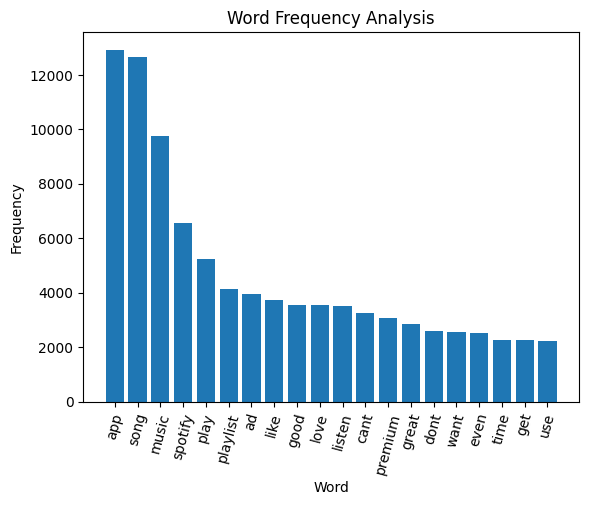

In [18]:
x_values = [word[0] for word in word_freq]
y_values = [word[1] for word in word_freq]

plt.bar(x_values, y_values)
plt.xlabel('Word')
plt.xticks(rotation=75)
plt.ylabel('Frequency')
plt.title('Word Frequency Analysis')

Sentiment Analysis

In [19]:
from textblob import TextBlob

df['sentiment_score'] = df['cleaned_text'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

In [20]:
def get_sentiment(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['sentiment_score'].apply(get_sentiment)


In [21]:
print(df['sentiment'].head(3))

0    positive
1    positive
2    positive
Name: sentiment, dtype: object


In [22]:
print(df['sentiment_score'].head(3))

0    0.420333
1    0.166667
2    0.100000
Name: sentiment_score, dtype: float64


Separate sentiments

In [23]:
positive_reviews = df[df['sentiment'] == 'positive']
negative_reviews = df[df['sentiment'] == 'negative']

In [24]:
pos_words = [word for tokens in positive_reviews['tokens'] for word in tokens]
neg_words = [word for tokens in negative_reviews['tokens'] for word in tokens]

# Share Phase

# Positive words

['great', 'music', 'service', 'audio', 'high', 'quality', 'app', 'easy', 'use', 'also', 'quick', 'friendly', 'support', 'please', 'ignore', 'previous', 'negative', 'rating', 'app', 'super', 'great', 'give', 'five', 'star', 'popup', 'get', 'best', 'spotify', 'experience', 'android', '12', 'annoying', 'please', 'let', 'get', 'rid', 'love', 'selection', 'lyric', 'provided', 'song', 'youre', 'listening', 'great', 'app', 'best', 'mp3', 'music', 'app', 'ever', 'used', 'one', 'problem', 'cant', 'play', 'song', 'find', 'song', 'despite', 'app', 'wonderful', 'recommend', 'best', 'love', 'spotify', 'usually', 'app', 'best', 'others', 'stated', 'control', 'button', 'disappear', 'podcasts', 'stop', 'reason', 'fixed', 'deleting', 'reinstalling', 'app', 'first', 'world', 'problem', 'sure', 'highly', 'annoying', 'nonetheless', 'especially', 'paying', 'prime', 'amazon', 'premium', 'music', 'family', 'package', 'good', 'everyone', 'could', 'listen', 'whatever', 'liked', 'respective', 'alexas', 'room', 

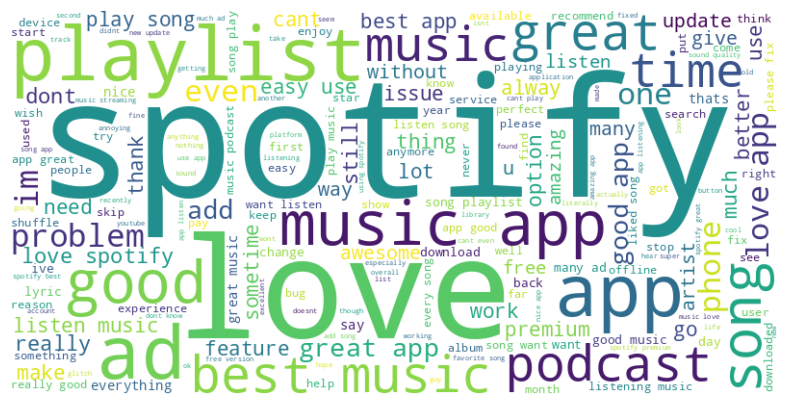

In [25]:
print(pos_words)


from wordcloud import WordCloud

pos_text = " ".join(pos_words)

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='viridis').generate(pos_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Negative words

['really', 'buggy', 'terrible', 'use', 'recently', 'still', 'extremely', 'slow', 'changing', 'storage', 'external', 'sd', 'card', 'im', 'convinced', 'done', 'purpose', 'spotify', 'know', 'issue', 'done', 'nothing', 'solve', 'time', 'changed', 'sd', 'card', 'faster', 'read', 'write', 'speedsall', 'samsung', 'brand', 'please', 'add', 'dont', 'like', 'song', 'never', 'appear', 'search', 'playlist', 'im', 'deleting', 'app', 'following', 'reason', 'app', 'failing', 'business', 'model', 'whether', 'streaming', 'service', 'like', 'consumer', 'doesnt', 'want', 'pay', 'music', 'cant', 'fully', '6', 'ad', 'successively', 'upon', 'logging', 'single', 'song', 'much', 'closed', 'app', 'ad', 'number', '6', 'im', 'patient', 'way', 'profit', 'youve', 'already', 'peaked', 'thats', 'left', 'decline', 'worst', 'app', 'always', 'say', 'im', 'offline', 'never', 'showed', 'song', 'podcast', 'cant', 'listen', 'downloaded', 'playlist', 'im', 'offline', 'whats', 'point', 'feature', 'disappointed', 'always', 'c

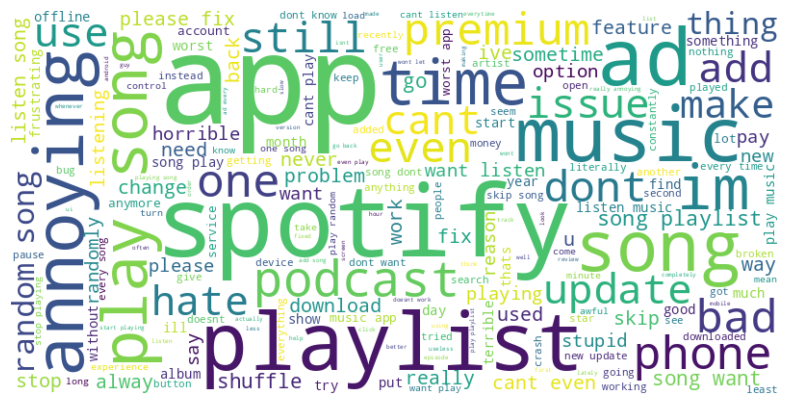

In [26]:
print(neg_words)
from wordcloud import WordCloud

pos_text = " ".join(neg_words)

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='viridis').generate(pos_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

<Axes: xlabel='sentiment'>

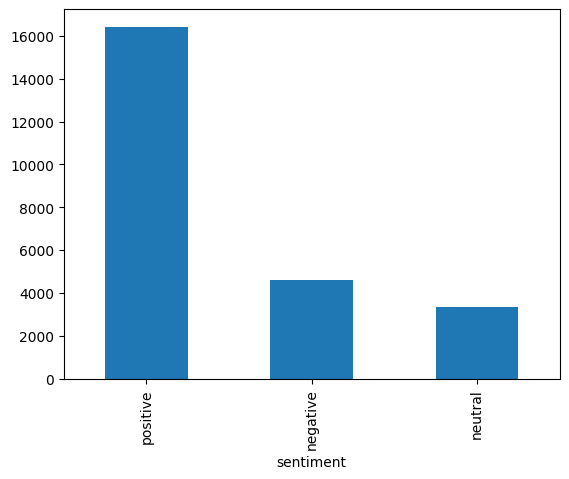

In [27]:
df['sentiment'].value_counts().plot(kind='bar')

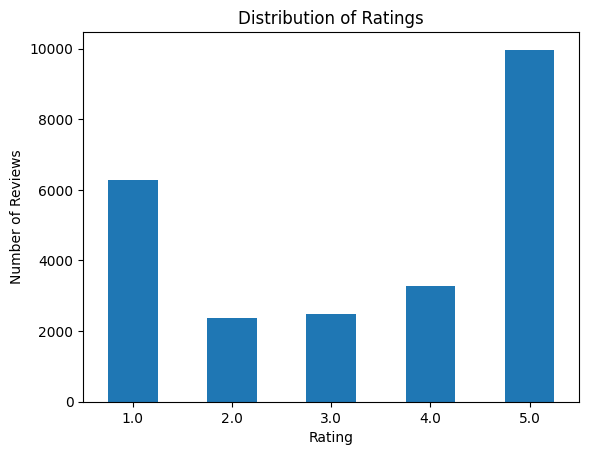

In [28]:
df['Rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

# **Summary**

1.Predominantly Positive Sentiment: The overall sentiment analysis shows a strong inclination towards positive reviews, with a significant majority of users expressing satisfaction.

2.Key User Mentions: The most frequently mentioned words across all reviews are 'app', 'song', and 'music', indicating that these are central aspects of user experience.

3.Common Negative Feedback: Recurring themes in negative reviews revolve around 'buggy' performance, 'terrible' user experience, 'ads', and issues like 'crashing' or being 'offline'.

4.Positive User Experience Highlights: Users frequently praise the 'great' 'music' 'service', 'audio' 'quality', 'selection', 'lyrics', and the app's ease of 'use', and often express 'love' for it.

5.Polarized Rating Distribution: The ratings distribution is likely polarized, with a high number of both 5-star and 1-star reviews, which is common for apps where users often leave feedback only when they are extremely satisfied or extremely dissatisfied.